Using device:        cuda


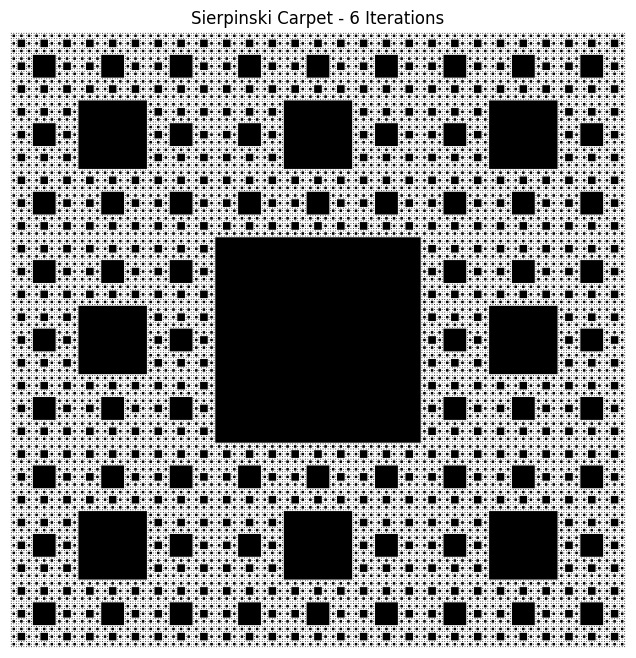

Theoretical fractal dimension: 1.892789260714372


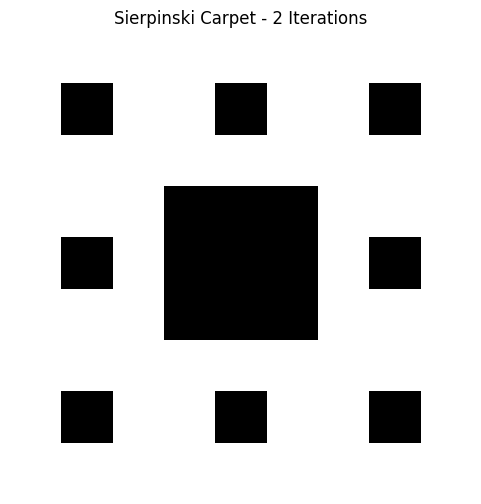

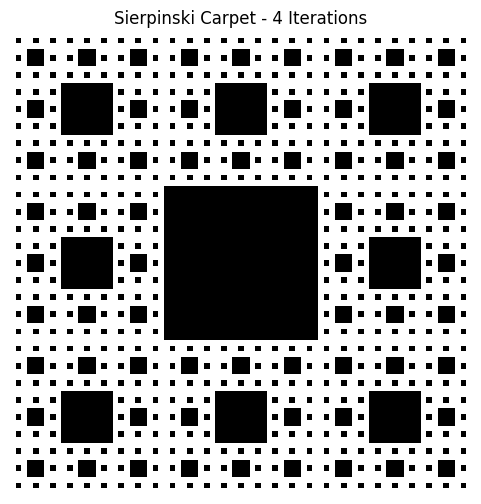

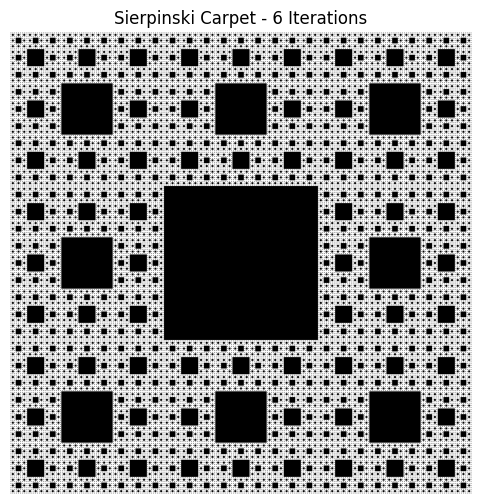

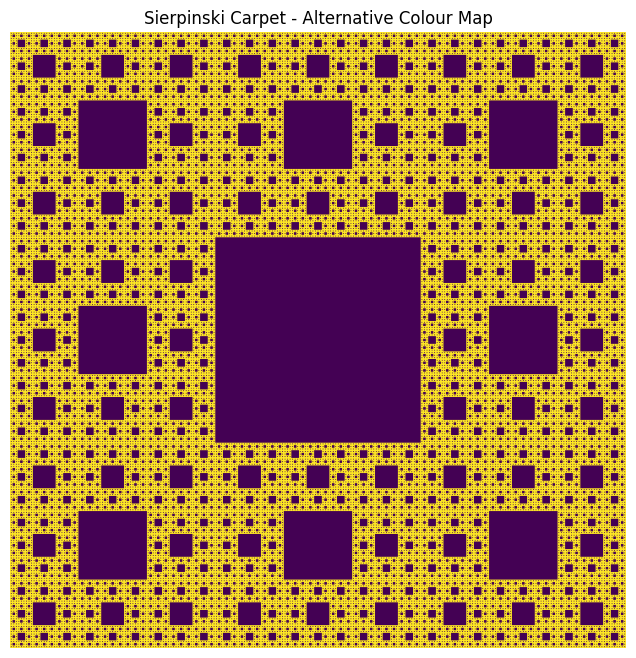

In [7]:
# pytorch tensors decide which pixels are removed vs remain


# parallelism is going to work thorugh the entire coordinate of tensors rather then manually checking each pixel with nested loops.


#for analysis i need to calculate the theoretical fractal dimension
"""
Then show 2-3 iteration depths or visualisations so theres more than one prompt one picture
need a readme + a few meaningful commits, and the notebook/code

"""


import torch
import matplotlib.pyplot as plt
import math

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:       ", device)

iterations = 6 # because we're building a 729x729 grid we have 6 iterations to divide the carpet
size = 3 ** iterations # the carpet divides each square into thirds per iteration

# creates coordinate values for both axes
y = torch.arange(size, device=device)
x = torch.arange(size, device=device)


#2d coordinate tensors created from mashing btoh 1d coordinates lists tg
Y, X = torch.meshgrid(y, x, indexing='ij')

#carpet mask to know what pixels turned off and on
carpet = torch.ones((size, size), dtype=torch.bool, device=device)

x_temp = X.clone()
y_temp = Y.clone()

for i in range(iterations):
    center_square = (x_temp % 3 == 1) & (y_temp % 3 == 1)

    carpet &= ~center_square

    x_temp//= 3
    y_temp //= 3

plt.figure(figsize=(8, 8))

plt.imshow(
    carpet.cpu().numpy(),
    cmap="gray"
)

plt.title(f"Sierpinski Carpet - {iterations} Iterations")
plt.axis("off")
plt.show()

# Theoretical fractal dimension
dimension = math.log(8) / math.log(3)

print("Theoretical fractal dimension:", dimension)



#ANALYSIS PART

#helper function to visualise various carpet depths

def generate_carpet(iterations, device):
    size = 3 ** iterations

    y = torch.arange(size, device=device)
    x = torch.arange(size, device=device)

    Y, X = torch.meshgrid(y, x, indexing='ij')

    carpet = torch.ones(
        (size, size),
        dtype=torch.bool,
        device=device
    )

    x_temp = X.clone()
    y_temp = Y.clone()

    for i in range(iterations):
        center_square = (
            (x_temp % 3 == 1) &
            (y_temp % 3 == 1)
        )

        carpet &= ~center_square

        x_temp //= 3
        y_temp //= 3

    return carpet

#plotting to show progression in depths
for depth in [2, 4, 6]:
    carpet = generate_carpet(depth, device)

    plt.figure(figsize=(6, 6))
    plt.imshow(carpet.cpu().numpy(), cmap="gray")
    plt.title(f"Sierpinski Carpet - {depth} Iterations")
    plt.axis("off")
    plt.show()







#alternative visualisation

carpet = generate_carpet(6, device)

plt.figure(figsize=(8, 8))
plt.imshow(carpet.cpu().numpy(), cmap="viridis")
plt.title("Sierpinski Carpet - Alternative Colour Map")
plt.axis("off")
plt.show()

SyntaxError: invalid syntax (3561636281.py, line 1)